In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import os

WD =  os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(WD, "..", ".."))
RESULTS = os.path.join(BASE_DIR, "data", "results", "stamina", "stamina_test_results.csv")

df = pd.read_csv(RESULTS)

cols = [
    "build_time_us",
    "query_time_us",
    "memory_bytes"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["is_timeout"] = df["build_time_us"].isna()

In [140]:
clean = df[df["is_timeout"] == False].copy()

clean["build_time_us"] = clean["build_time_us"] / 1000
clean["query_time_us"] = clean["query_time_us"] / 1000
clean["memory_bytes"] = clean["memory_bytes"] / (1024 * 1024)

clean = clean.rename(columns={
    "build_time_us": "build_time_ms",
    "query_time_us": "query_time_ms",
    "memory_bytes": "memory_mib"
})

clean

,dataset,status,impl,positive_set_size,negative_set_size,number_of_queries,build_time_ms,query_time_ms,memory_mib,total_output_len,is_timeout
0,1_training,OK,naive,6,4,38084,0.029,2.629,0.001923,75894,False
1,1_training,OK,precomp,6,4,38084,0.215,1.668,0.041756,75894,False
2,1_training,OK,sqrt,6,4,38084,0.437,4.265,0.040371,75894,False
3,1_training,OK,naive,6,4,38084,0.014,1.396,0.001923,75894,False
4,1_training,OK,precomp,6,4,38084,0.222,1.472,0.041756,75894,False
...,...,...,...,...,...,...,...,...,...,...,...
1480,99_training,OK,precomp,604,620,33675,24.649,4.058,5.651722,71158,False
1481,99_training,OK,sqrt,604,620,33675,12.834,3.173,3.212715,71158,False
1482,99_training,OK,naive,604,620,33675,0.563,4.372,0.164642,71158,False
1483,99_training,OK,precomp,604,620,33675,24.282,4.156,5.651722,71158,False


In [141]:
summary = (
    clean.groupby(["dataset", "impl"])
        .agg(
            build_mean_ms=("build_time_ms", "mean"),
            build_std_ms=("build_time_ms", "std"),
            query_mean_ms=("query_time_ms", "mean"),
            query_std_ms=("query_time_ms", "std"),
            memory_mib=("memory_mib", "mean"),
            num_pos=("positive_set_size", "first"),
            num_neg=("negative_set_size", "first"),
            num_queries=("number_of_queries", "first"),
        )
        .reset_index()
)

summary["total_mean_ms"] = (
    summary["build_mean_ms"] +
    summary["query_mean_ms"]
)

summary["query_ms_per_query"] = (
    summary["query_mean_ms"] /
    summary["num_queries"]
)

summary["num_traces"] = (
    summary["num_pos"] +
    summary["num_neg"]
)


summary

,dataset,impl,build_mean_ms,build_std_ms,query_mean_ms,query_std_ms,memory_mib,num_pos,num_neg,num_queries,total_mean_ms,query_ms_per_query,num_traces
0,10_training,naive,0.7032,0.294620,11.3040,1.288068,0.246948,1687,2328,36750,12.0072,0.000308,4015
1,10_training,precomp,280.1608,54.905375,10.4838,4.838215,24.775658,1687,2328,36750,290.6446,0.000285,4015
2,10_training,sqrt,24.3408,4.547249,9.2850,1.139209,5.632122,1687,2328,36750,33.6258,0.000253,4015
3,11_training,naive,0.9054,0.354103,10.5042,3.227104,0.370422,1194,1069,21391,11.4096,0.000491,2263
4,11_training,precomp,135.5680,18.612525,6.4464,2.144914,18.176605,1194,1069,21391,142.0144,0.000301,2263
...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,99_training,precomp,28.2344,8.267582,4.0076,0.265717,5.651722,604,620,33675,32.2420,0.000119,1224
293,99_training,sqrt,18.6460,8.302769,4.1416,1.603489,3.212715,604,620,33675,22.7876,0.000123,1224
294,9_training,naive,1.5870,0.365708,11.7490,2.084746,0.833435,2560,2674,22823,13.3360,0.000515,5234
295,9_training,precomp,914.7982,59.042791,8.6038,0.356490,81.999733,2560,2674,22823,923.4020,0.000377,5234


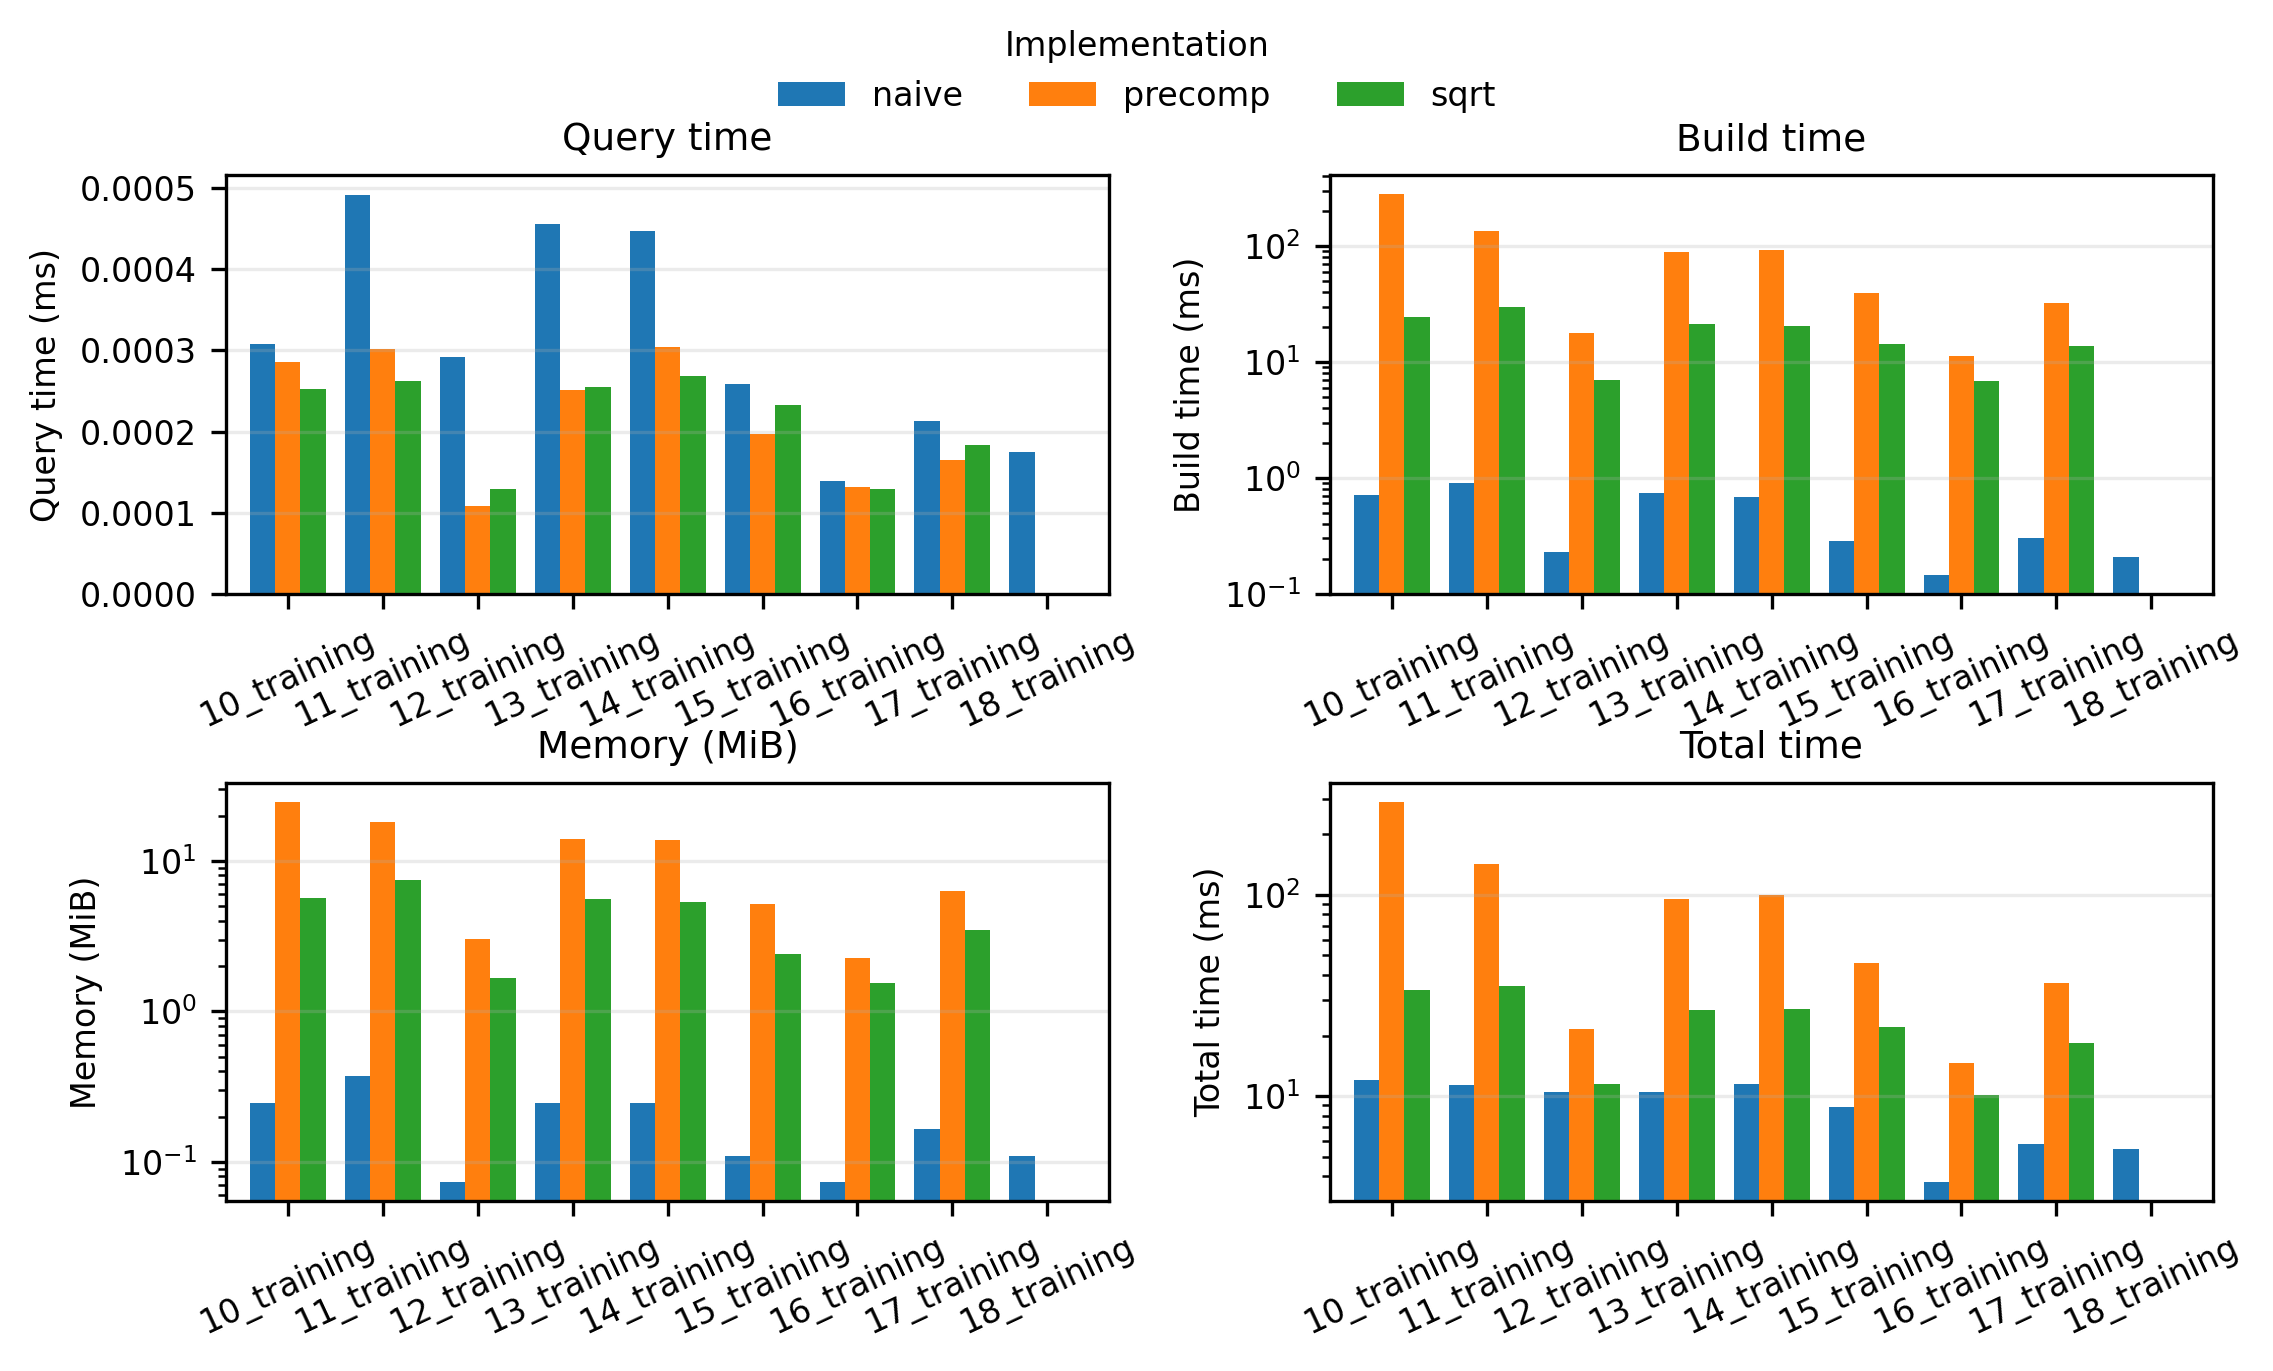

In [142]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.5), dpi=300)

metrics = [
    ("query_ms_per_query", "Query time (ms)", False),
    ("build_mean_ms", "Build time (ms)", True),
    ("memory_mib", "Memory (MiB)", True),
    ("total_mean_ms", "Total time (ms)", True),
]

for ax, (metric, ylabel, use_log) in zip(axes.flat, metrics):
    pivot = summary[:25].pivot(
        index="dataset",
        columns="impl",
        values=metric
    )

    pivot.plot(
        kind="bar",
        ax=ax,
        width=0.8
    )

    ax.set_title(ylabel.replace(" (ms)", "") if "ms" in ylabel else ylabel)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    if use_log:
        ax.set_yscale("log")

    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Implementation",
    loc="upper center",
    ncol=min(len(labels), 4),
    frameon=False,
)

for ax in axes.flat:
    ax.legend().remove()

plt.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.12,
    top=0.88,
    wspace=0.25,
    hspace=0.45
)

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_17396\1519369374.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


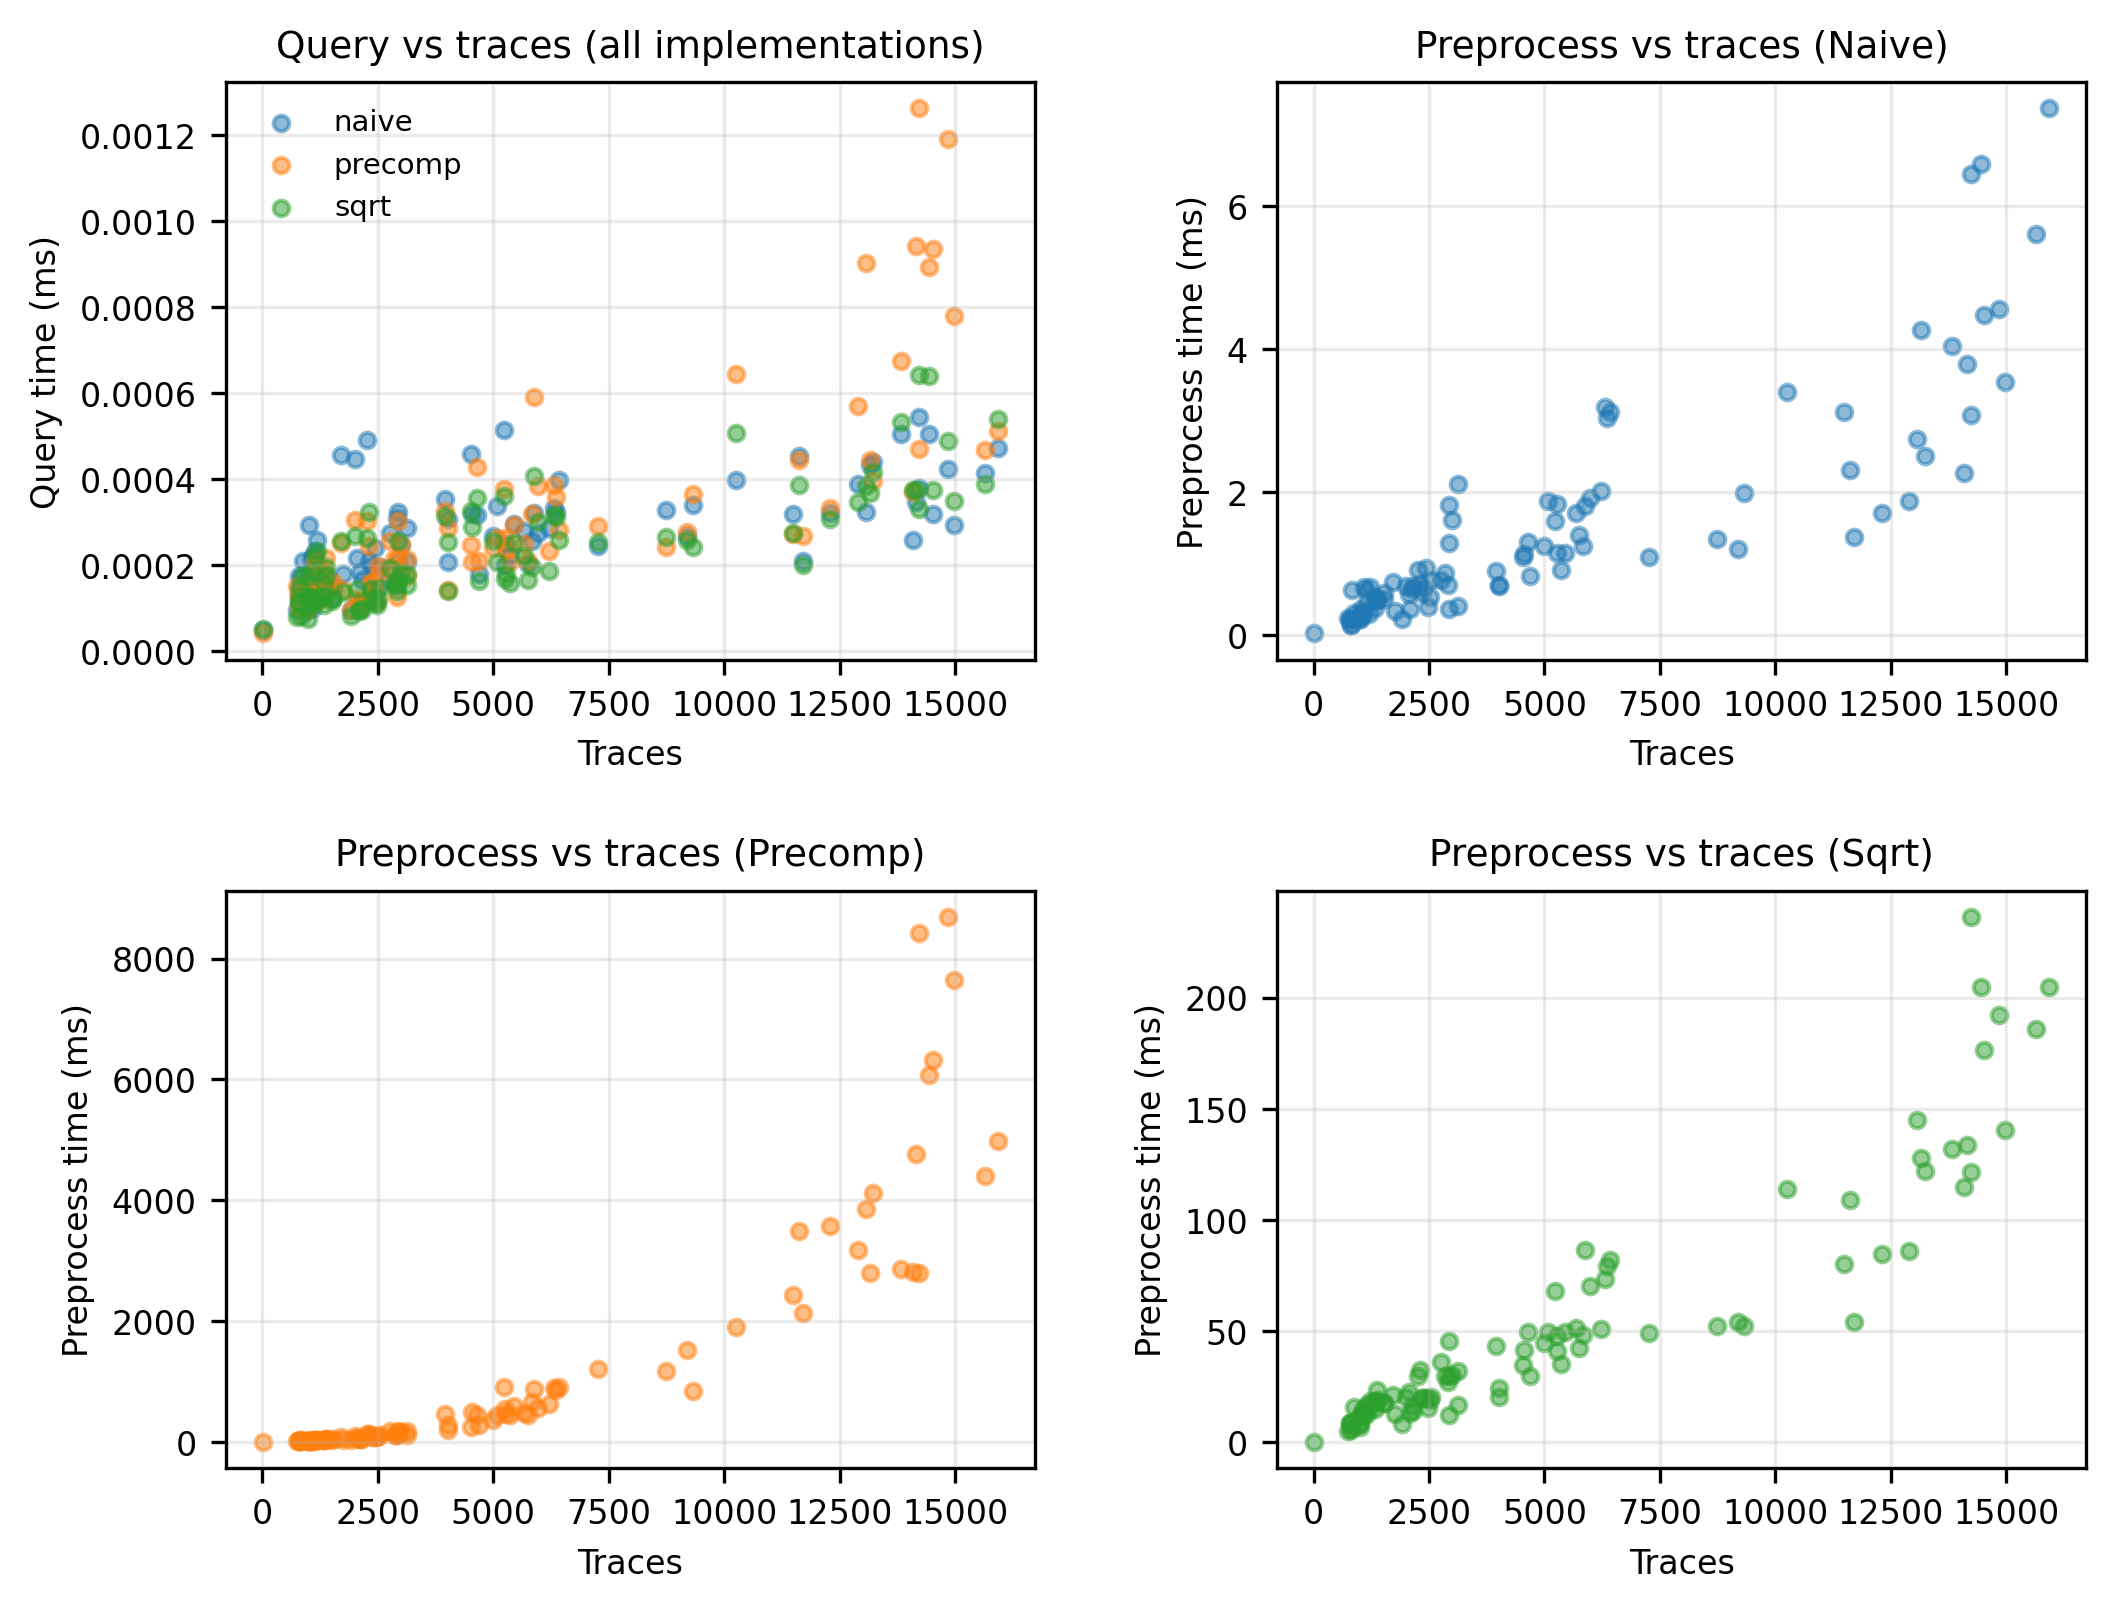

In [143]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

colors = {
    "naive": "tab:blue",
    "precomp": "tab:orange",
    "sqrt": "tab:green"
}


from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8, 6), dpi=300)


gs = GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.4)


ax00 = fig.add_subplot(gs[0, 0])

for impl in ["naive", "precomp", "sqrt"]:
    sub = summary[summary["impl"] == impl].sort_values("num_traces")
    ax00.scatter(
        sub["num_traces"],
        sub["query_ms_per_query"],
        s=14,
        alpha=0.5,
        color=colors[impl],
        label=impl
    )

ax00.set_title("Query vs traces (all implementations)")
ax00.set_xlabel("Traces")
ax00.set_ylabel("Query time (ms)")
ax00.grid(alpha=0.25)
ax00.legend(frameon=False, fontsize=7)


ax01 = fig.add_subplot(gs[0, 1])

sub = summary[summary["impl"] == "naive"].sort_values("num_traces")
ax01.scatter(sub["num_traces"], sub["build_mean_ms"], s=14, alpha=0.5, color=colors["naive"])

ax01.set_title("Preprocess vs traces (Naive)")
ax01.set_xlabel("Traces")
ax01.set_ylabel("Preprocess time (ms)")
ax01.grid(alpha=0.25)

ax10 = fig.add_subplot(gs[1, 0])

sub = summary[summary["impl"] == "precomp"].sort_values("num_traces")
ax10.scatter(sub["num_traces"], sub["build_mean_ms"], s=14, alpha=0.5, color=colors["precomp"])

ax10.set_title("Preprocess vs traces (Precomp)")
ax10.set_xlabel("Traces")
ax10.set_ylabel("Preprocess time (ms)")
ax10.grid(alpha=0.25)

ax11 = fig.add_subplot(gs[1, 1])

sub = summary[summary["impl"] == "sqrt"].sort_values("num_traces")
ax11.scatter(sub["num_traces"], sub["build_mean_ms"], s=14, alpha=0.5, color=colors["sqrt"])

ax11.set_title("Preprocess vs traces (Sqrt)")
ax11.set_xlabel("Traces")
ax11.set_ylabel("Preprocess time (ms)")
ax11.grid(alpha=0.25)

plt.tight_layout()
plt.show()

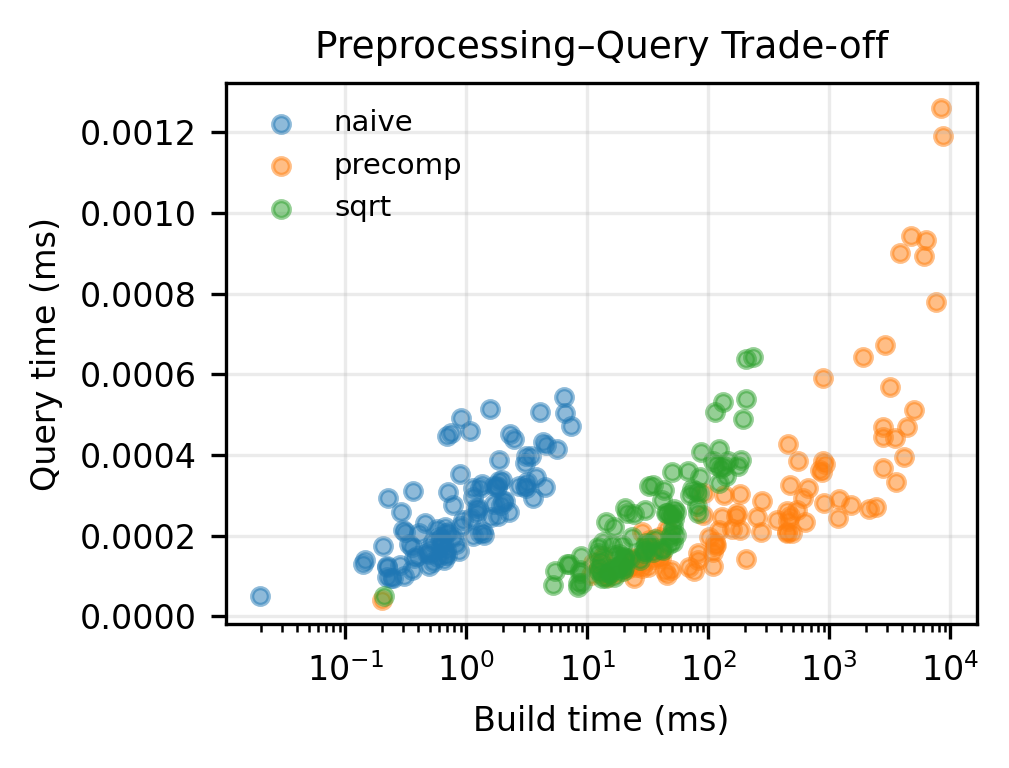

In [144]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=300)

impls = summary["impl"].unique()

for impl in impls:
    sub = summary[summary["impl"] == impl]
    ax.scatter(
        sub["build_mean_ms"],
        sub["query_ms_per_query"],
        s=16,
        alpha=0.5,
        label=impl
    )

ax.set_title("Preprocessing–Query Trade-off")
ax.set_xlabel("Build time (ms)")
ax.set_ylabel("Query time (ms)")
ax.set_xscale("log")
ax.grid(alpha=0.25)

ax.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.show()